In [2]:
import os

print(os.getcwd())
print(os.listdir("../results"))

import pandas as pd

descriptor_df = pd.read_csv("../results/descriptors.csv")


d:\triazine_qspr_project\notebooks
['descriptors.csv', 'filtered_hydrazide.csv', 'similarity_matrix.csv', 'triazine_dataset.csv']


In [3]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.DataStructs import TanimotoSimilarity
from rdkit.Chem import rdFingerprintGenerator

mols = [Chem.MolFromSmiles(s) for s in descriptor_df["smiles"]]

morgan = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

fps = [morgan.GetFingerprint(mol) for mol in mols]


mat = []

for i in fps:
    row = []
    for j in fps:
        row.append(TanimotoSimilarity(i, j))
    mat.append(row)

sim_df = pd.DataFrame(
    mat,
    index=descriptor_df["compound_id"],
    columns=descriptor_df["compound_id"]
)

sim_df

compound_id,Tz-Ph,Tz-2OH,Tz-4Cl,Tz-tBu,Tz-4NO2,Tz-4OH,Tz-2Cl,Tz-4Py,Tz-2Py,Bis-Tz,Tris-Tz,Thio-Tz
compound_id,,,,,,,,,,,,
Tz-Ph,1.000000,0.548387,0.642857,0.600000,0.545455,0.642857,0.548387,0.666667,0.548387,0.571429,0.640000,0.441176
Tz-2OH,0.548387,1.000000,0.428571,0.405405,0.375000,0.515152,0.625000,0.441176,0.485714,0.500000,0.451613,0.394737
Tz-4Cl,0.642857,0.428571,1.000000,0.612903,0.558824,0.655172,0.515152,0.620690,0.428571,0.483871,0.592593,0.500000
Tz-tBu,0.600000,0.405405,0.612903,1.000000,0.527778,0.612903,0.405405,0.580645,0.405405,0.454545,0.551724,0.394737
Tz-4NO2,0.545455,0.375000,0.558824,0.527778,1.000000,0.558824,0.375000,0.529412,0.375000,0.416667,0.500000,0.365854
Tz-4OH,0.642857,0.515152,0.655172,0.612903,0.558824,1.000000,0.428571,0.620690,0.428571,0.483871,0.592593,0.416667
Tz-2Cl,0.548387,0.625000,0.515152,0.405405,0.375000,0.428571,1.000000,0.441176,0.485714,0.500000,0.451613,0.472222
Tz-4Py,0.666667,0.441176,0.620690,0.580645,0.529412,0.620690,0.441176,1.000000,0.484848,0.500000,0.615385,0.428571
Tz-2Py,0.548387,0.485714,0.428571,0.405405,0.375000,0.428571,0.485714,0.484848,1.000000,0.655172,0.451613,0.394737


In [4]:
sim_df.to_csv(
    "../results/similarity_matrix.csv",
    index=False
)

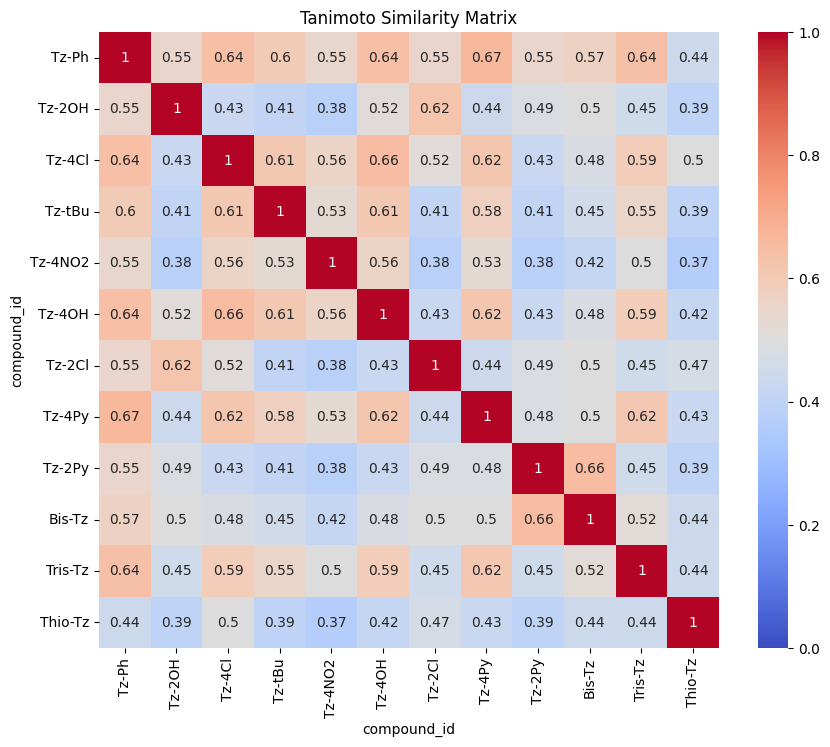

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(sim_df,
            annot=True,
            cmap="coolwarm",    
            vmin=0,            
            vmax=1,            
            center=0.5,)

plt.title("Tanimoto Similarity Matrix")
plt.show()

In [6]:
max_sim = 0  #coz fps range from 0 to 1
pair = ()   # empty set

for i in range(len(fps)):   #suppose len(fps) = 12, loops from 0 to 11
    for j in range(i+1, len(fps)):  #nest loop compares eg: (1,0), (2,0),...and to avoid (0,0),(1,1) coz both will be same molecule
        sim = TanimotoSimilarity(fps[i], fps[j])    # find the similarity values of every i and j

        if sim > max_sim:       #if generated sim greater than max_sim, do the following condition
            max_sim = sim       
            pair = (
                descriptor_df.iloc[i]["compound_id"],       #the row no. of the comp goes into i and their compound id stores in pair
                descriptor_df.iloc[j]["compound_id"]
            )

print("Most similar pair:", pair)
print("Similarity =", round(max_sim,3))

avg_sim = sim_df.mean(axis=1)

avg_sim.sort_values()

Most similar pair: ('Tz-Ph', 'Tz-4Py')
Similarity = 0.667


compound_id
Thio-Tz    0.473948
Tz-4NO2    0.510651
Tz-2Py     0.511978
Tz-2OH     0.514230
Tz-2Cl     0.520687
Bis-Tz     0.543771
Tz-tBu     0.545954
Tris-Tz    0.566929
Tz-4Py     0.577438
Tz-4OH     0.579656
Tz-4Cl     0.586600
Tz-Ph      0.616300
dtype: float64

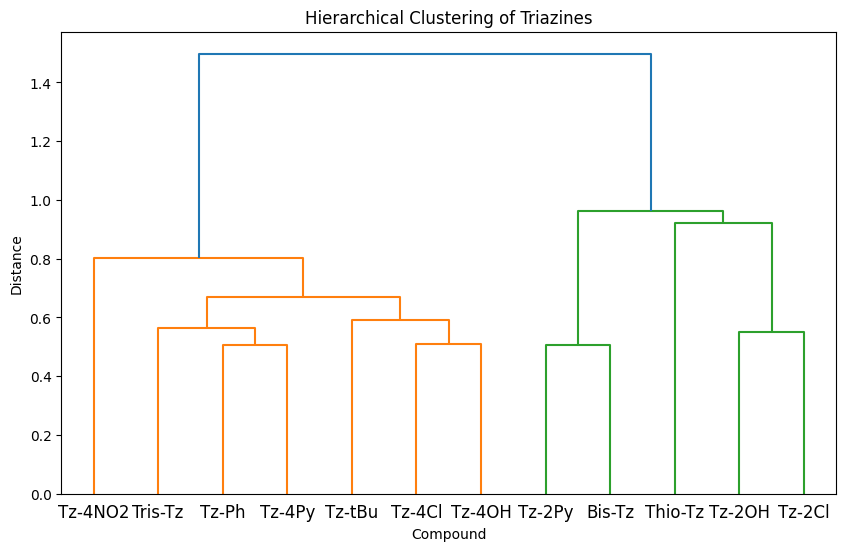

In [7]:
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(sim_df, method='ward')

plt.figure(figsize=(10,6))

dendrogram(
    linked,
    labels=descriptor_df["compound_id"].tolist()
)

plt.title("Hierarchical Clustering of Triazines")
plt.xlabel("Compound")
plt.ylabel("Distance")

plt.show()


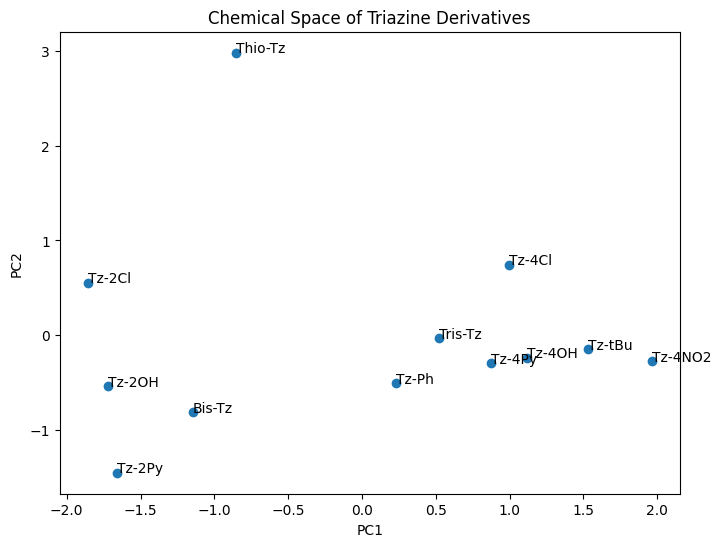

[0.22869637 0.14641794]


In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from rdkit.DataStructs import ConvertToNumpyArray

fp_array = []

for fp in fps:
    arr = np.zeros((2048,), dtype=int)
    ConvertToNumpyArray(fp, arr)
    fp_array.append(arr)

fp_array = np.array(fp_array)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(fp_array)
pca_df = descriptor_df.copy()

pca_df["PC1"] = pca_result[:,0]
pca_df["PC2"] = pca_result[:,1]
pca_df[["compound_id","PC1","PC2"]]

plt.figure(figsize=(8,6))
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"]
)

for i, txt in enumerate(pca_df["compound_id"]):
    plt.annotate(
        txt,
        (pca_df["PC1"][i], pca_df["PC2"][i])
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Chemical Space of Triazine Derivatives")
plt.show()

print(pca.explained_variance_ratio_)
